## Generalized Lotka-Volterra

In [16]:
%%capture
%load_ext autoreload
%autoreload 2
%reset -f
# %pip install matplotlib

In [18]:
import jax
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt

import sys
import os

# Add the parent folder (OTF) to sys.path
project_root = os.path.abspath(os.path.join("..", "..", "src"))
sys.path.append(project_root)

import otf
from otf import optim
from otf import time_integration as ti
from otf.asyncd import utils
from otf.system import System_ModelKnown

from plot import plot

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)

jndarray = jnp.ndarray

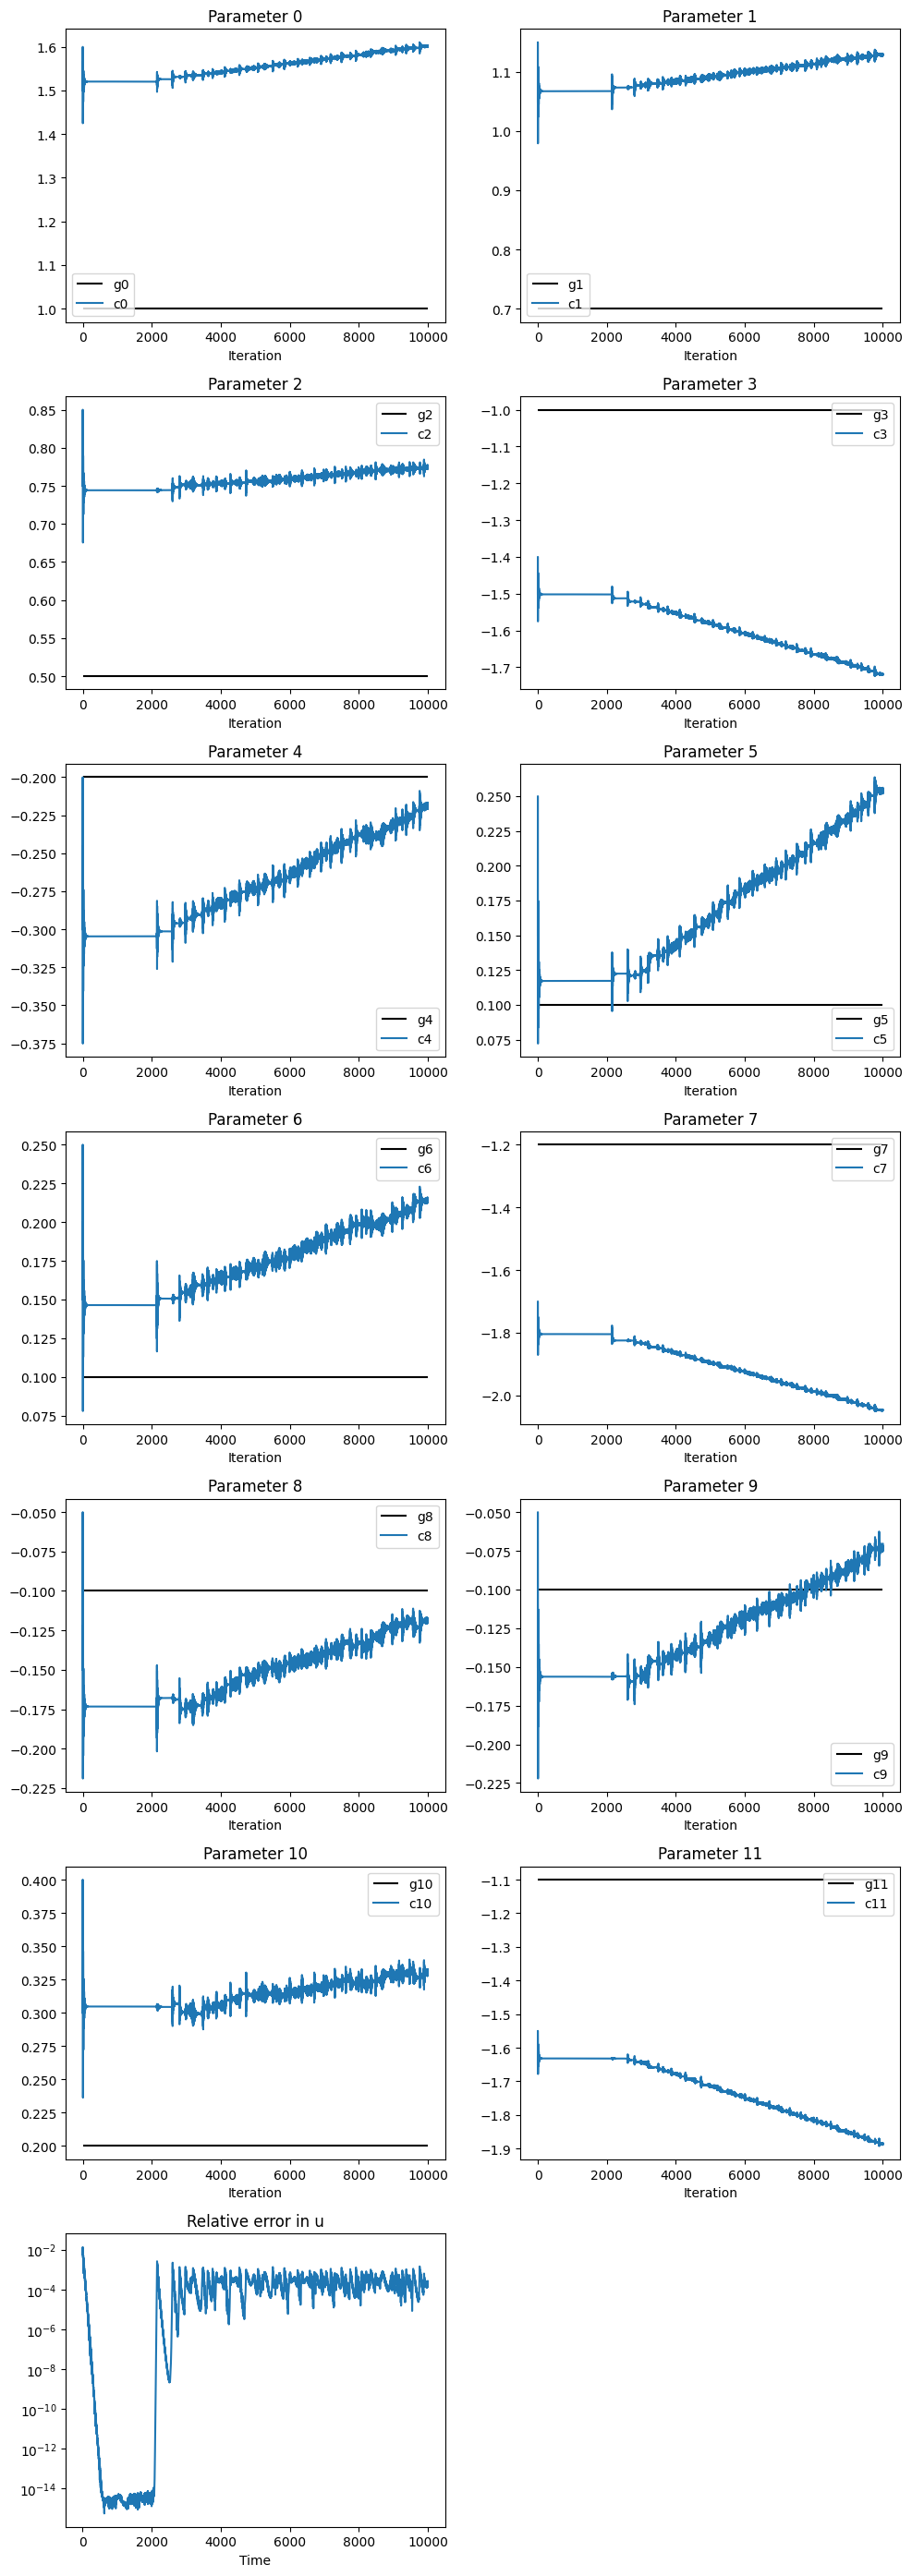

In [20]:
def get_initial_values():
    u0 = jnp.array([1.0, 0.8, 1.2])
    un0 = u0
    return u0, un0

def lotka_volterra(gs: jndarray, x: jndarray) -> jndarray:
    """
    gs contains parameters:
        first N entries  -> growth rates b
        remaining N*N    -> flattened interaction matrix A
    """
    N = x.shape[0]

    b = gs[:N]
    A = gs[N:].reshape((N, N))

    dx = x * (b + A @ x)

    return dx

N = 3

b = jnp.array([1.0, 0.7, 0.5])

A = jnp.array([
    [-1.0, -0.2, 0.1],
    [0.1, -1.2, -0.1],
    [-0.1, 0.2, -1.1]
])

gs = jnp.concatenate([b, A.flatten()])
cs = gs * 1.5

mu = 20

true0, assimilated0 = get_initial_values()

observed_slice = jnp.s_[:]
observed_mask = otf.system.utils.mask_from_slice(observed_slice, true0.shape)
system = System_ModelKnown(mu, gs, cs, observed_mask, lotka_volterra, lotka_volterra)

solver = ti.ForwardEuler(system)
# solver = ti.RK4(system)
solver = ti.TwoStepAdamsBashforth(system, solver)
# optimizer = base_optim.LevenbergMarquardt(system, 1e-2)
optimizer = optax.adam(1e-1)
optimizer = optim.OptaxWrapper(system, optimizer)

# Simulation parameters
dt = 0.01
T0, Tf = 0, 10000
t_relax = 1

true_solver = solver
trues, tls_ = true_solver.solve_true(true0, T0, Tf, dt)

true_observed = trues[:, system.observed_mask]

cs, u_errors, tls, assimilateds = utils.run_update(
    system,
    true_observed,
    solver,
    dt,
    T0,
    Tf,
    t_relax,
    assimilated0,
    optimizer=optimizer,
    return_all=True,
)


fig, axs = plot(cs, u_errors, gs, tls)
plt.show()